# U-238 Radioactive Decay Chain Simulation

This notebook will simulate the U-238 decay chain using Bateman equations. We calculate how the activity of each isotope evolves over time, starting from pure U-238.

In [69]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

In [70]:
# Half lives in years
half_lives = {
    'U-238': 4.468e9,
    'Th-234': 24.1 / 365,
    'Pa-234': 1.17 / (365 * 24 * 60),
    'U-234': 2.455e5,
    'Th-230': 7.538e4,
    'Ra-226': 1600,
    'Rn-222': 3.8235 / 365,
    'Po-218': 3.05 / (365 * 24 * 60),
    'Pb-214': 26.8 / (365 * 24 * 60),
    'Bi-214': 19.7 / (365 * 24 * 60),
    'Po-214': 1.643e-4 / (365 * 24 * 60 * 60),
    'Pb-210': 22.3,
    'Bi-210': 5.013 / 365,
    'Po-210': 138.4 / 365,
    'Pb-206': np.inf #stable, no decay
}

## Data Sources
Half life data sourced from the National Nuclear Data Centre (NNDC), 
Brookhaven National Laboratory. https://www.nndc.bnl.gov 

## Decay Constants
We calculate the decay constant for each isotope using: 
λ = ln(2) / half-life

In [71]:
# Calculate decay constants in units of 1/year:
decay_constants = {}
for isotope, hl in half_lives.items():
    if hl == np.inf:
        decay_constants[isotope] = 0 # stable isotope no decay 
    else:
        decay_constants[isotope] = np.log(2) / hl


# Print to verify
for isotope, lam in decay_constants.items():
    print(f"{isotope}: λ = {lam:.3e} per year")
    

U-238: λ = 1.551e-10 per year
Th-234: λ = 1.050e+01 per year
Pa-234: λ = 3.114e+05 per year
U-234: λ = 2.823e-06 per year
Th-230: λ = 9.195e-06 per year
Ra-226: λ = 4.332e-04 per year
Rn-222: λ = 6.617e+01 per year
Po-218: λ = 1.194e+05 per year
Pb-214: λ = 1.359e+04 per year
Bi-214: λ = 1.849e+04 per year
Po-214: λ = 1.330e+11 per year
Pb-210: λ = 3.108e-02 per year
Bi-210: λ = 5.047e+01 per year
Po-210: λ = 1.828e+00 per year
Pb-206: λ = 0.000e+00 per year


## Bateman Equations
We model the decay chain as a system of coupled ODEs.
Each isotope is produced by decay of its parent and lost through its own decay. 

In [72]:
# List of isotopes in order
isotopes = list(half_lives.keys())
lam = list(decay_constants.values())

def bateman(t, N):
    dNdt = np.zeros(len(isotopes))
    for i in range(len(isotopes)):
        # Loss fron own decay
        dNdt[i] -= lam[i] * N[i]
        # Production from parent
        if i > 0:
            dNdt[i] += lam[i-1] * N[i-1] 
    return dNdt


## Solving the System
We solve the Bateman Equations numerically using SciPy's solve_ivp function.
We start with pure U-238 and simulate over 10 billion years.

In [73]:
# Inital conditions start with pure U-238
# Using 1 as arbitrary numve of atoms

N0 = np.zeros(len(isotopes))
N0[0] = 1.0 # all U-238at t=0

# Time span in years
t_start = 0
t_end = 1e10 #10 billion years
t_span = (t_start, t_end)

# Time points where we want the solution
t_eval = np.logspace(0, 10, 1000) # 1000 points from 1 to 10 billion years

# Solve the system
solution = solve_ivp(
    bateman,
    t_span,
    N0,
    t_eval=t_eval,
    method='Radau', 
    rtol=1e-8,
    atol=1e-10
)

print("Solved successfully:", solution.success)
print("Message:", solution.message)


Solved successfully: True
Message: The solver successfully reached the end of the integration interval.


## Results

We plot the number of atoms of each isotope over time, starting fromm pure U-238.

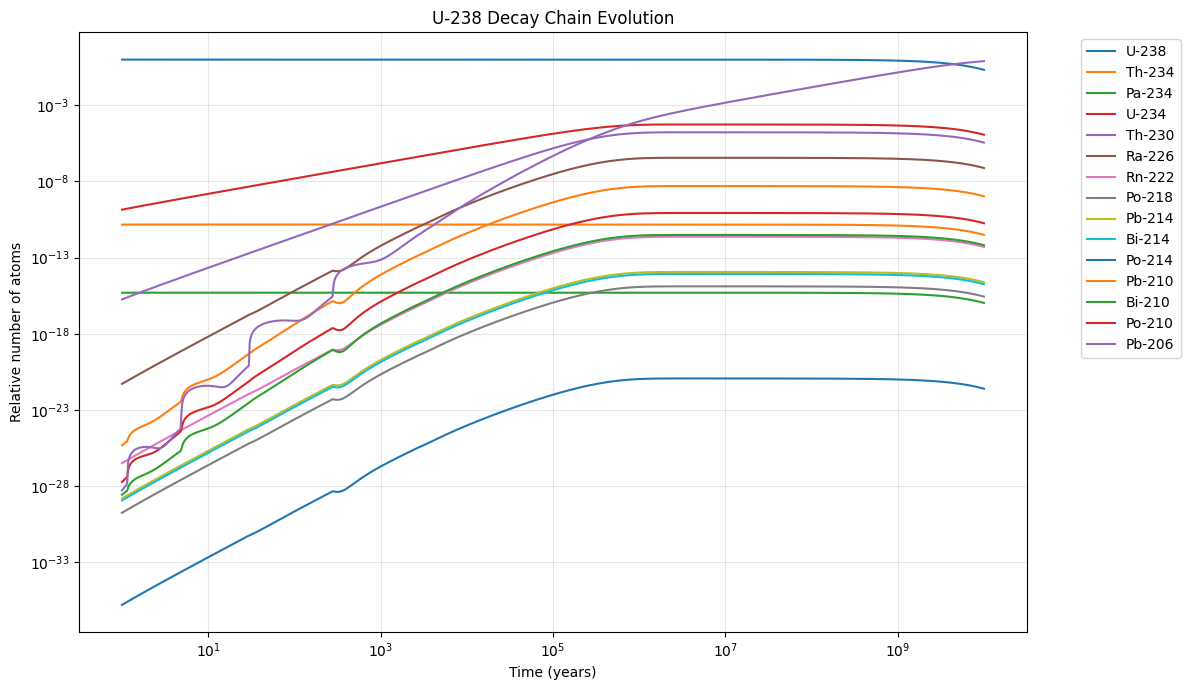

In [74]:
plt.figure(figsize=(12, 7))

for i, isotope in enumerate(isotopes):
    plt.plot(solution.t, solution.y[i], label=isotope)

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Time (years)')
plt.ylabel('Relative number of atoms')
plt.title('U-238 Decay Chain Evolution')
plt.legend(bbox_to_anchor=(1.05 ,1), loc='upper left')
plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()

## Activity

Activity is the rate ofdecay of each isotope measured in decays per year.
It is calculated as:

A = λ x N

Activity is what the Geigercounter physically measures and is more meaningful than raw atom counts.

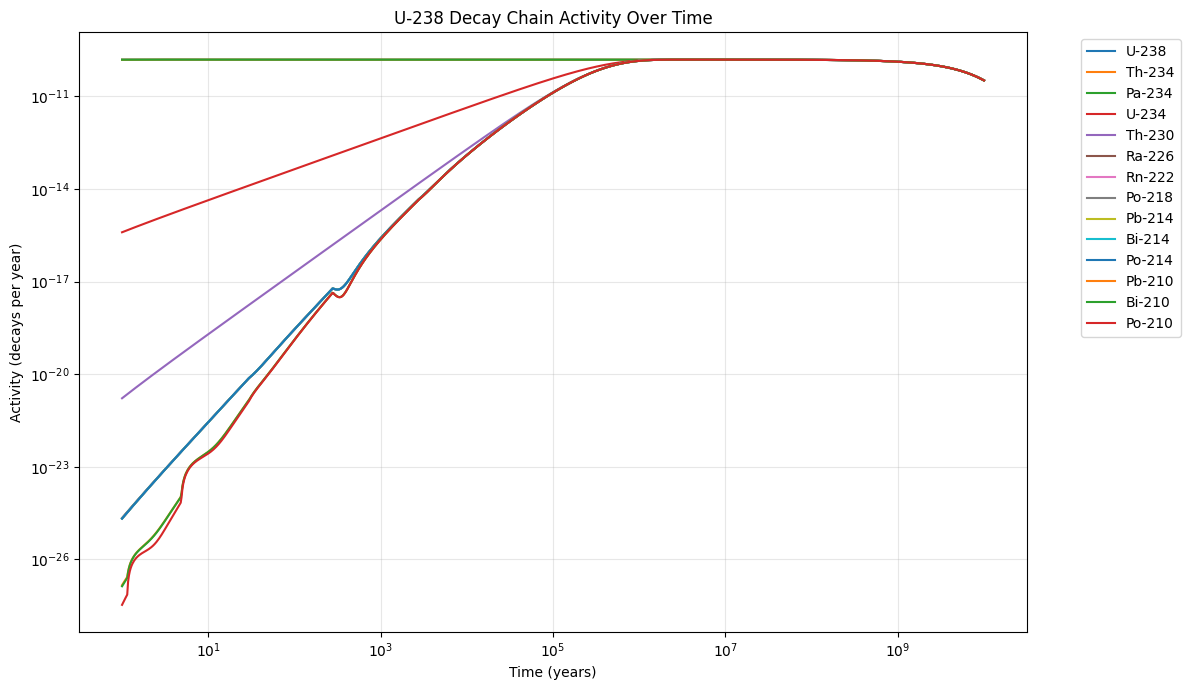

In [75]:
plt.figure(figsize=(12, 7))

for i, isotope in enumerate(isotopes[:-1]): # exclude stable Pb-206
    activity = decay_constants[isotope] * solution.y[i]
    plt.plot(solution.t, activity, label=isotope)

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Time (years)')
plt.ylabel('Activity (decays per year)')
plt.title('U-238 Decay Chain Activity Over Time')
plt.legend(bbox_to_anchor=(1.05 ,1), loc='upper left')
plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()

## Secular Equilibrium

After sufficient time, the activity of each isotope in the chain converges to the same value as U-238. This is called secular equilibrium; each isotope is being decayed as fast as it is being produced by its parent.

At secular equilibrium:
λ<sub>1</sub>N<sub>1</sub> = λ<sub>2</sub>N<sub>2</sub> = λ<sub>3</sub>N<sub>3</sub>

This means that short-lived isotopes exist on tiny quantities but decay rapidly, while long-lived isotopes accumulate in larger quantity but decay slowly. The net efffect will be equal across the chain


In [76]:
# Check activities at differnt time points
time_index = 500 # middle of time range
print(f"Time: {solution.t[time_index]:.2e} years")
print("-" * 45)
for i, isotope in enumerate(isotopes[:-1]):
    activity = decay_constants[isotope] * solution.y[i][time_index]
    if activity > 0:
        print(f"{isotope:10s}: {activity:.6e}")

Time: 1.01e+05 years
---------------------------------------------
U-238     : 1.551335e-10
Th-234    : 1.551335e-10
Pa-234    : 1.551335e-10
U-234     : 3.854271e-11
Th-230    : 1.399728e-11
Ra-226    : 1.348157e-11
Rn-222    : 1.348156e-11
Po-218    : 1.348156e-11
Pb-214    : 1.348156e-11
Bi-214    : 1.348156e-11
Po-214    : 1.348156e-11
Pb-210    : 1.347438e-11
Bi-210    : 1.347437e-11
Po-210    : 1.347425e-11


In [77]:
# Check activity at a time when short-lived isotopes have reached equilibrium but U-238has barely decayed (around 10,000 years is a good window)
check_time_years = 1e4
idx = np.argmin(np.abs(solution.t - check_time_years))

print(f"Time: {solution.t[idx]:.2e} years")
print("-" * 45)

for i, isotope in enumerate(isotopes[:-1]): # exclude stable Pb-206
    activity = decay_constants[isotope] * solution.y[i][idx]
    print(f"{isotope:10s}: {activity:6e}")

Time: 1.01e+04 years
---------------------------------------------
U-238     : 1.551357e-10
Th-234    : 1.551357e-10
Pa-234    : 1.551357e-10
U-234     : 4.358257e-12
Th-230    : 1.970256e-13
Ra-226    : 1.284234e-13
Rn-222    : 1.284230e-13
Po-218    : 1.284230e-13
Pb-214    : 1.284229e-13
Bi-214    : 1.284229e-13
Po-214    : 1.284229e-13
Pb-210    : 1.274706e-13
Bi-210    : 1.274701e-13
Po-210    : 1.274539e-13


In [78]:
# Check activitu at 2 million years - enough time for U-234 to rech equalibrium with U-238 bringing the whole chain into one equilibrium
check_time_years = 2e6
idx = np.argmin(np.abs(solution.t - check_time_years))

print(f"Time: {solution.t[idx]:.2e} years")
print("-" * 45)

for i, isotope in enumerate(isotopes[:-1]): # exclude stable Pb-206
    activity = decay_constants[isotope] * solution.y[i][idx]
    print(f"{isotope:10s}: {activity:6e}")

Time: 1.98e+06 years
---------------------------------------------
U-238     : 1.550883e-10
Th-234    : 1.550883e-10
Pa-234    : 1.550883e-10
U-234     : 1.545148e-10
Th-230    : 1.542595e-10
Ra-226    : 1.542540e-10
Rn-222    : 1.542540e-10
Po-218    : 1.542540e-10
Pb-214    : 1.542540e-10
Bi-214    : 1.542540e-10
Po-214    : 1.542540e-10
Pb-210    : 1.542539e-10
Bi-210    : 1.542539e-10
Po-210    : 1.542539e-10


## Conclusions

This simulation demonstrates several key features of radioactive decay chains:

1. **Vastly differnt timescales** - decay constants in this chain span over 20 orders of magnitude, from U-238 (billions of years) to Po-214 (microseconds). This mad the system numerically stiff, requiring the Radau method rather than standard explicit solvers.

2. **Secular equilibrium** — after a sufficiently long time, short-lived daughter 
isotopes reach an equilibrium where their activity matches that of the slow-decaying 
parent, U-238. This is why naturally occurring uranium ore contains measurable 
quantities of its short-lived daughter products even though they decay almost instantly.

3. **Practical relevance** — this kind of modelling underpins nuclear waste 
management, radiation dosimetry, and the interpretation of natural radioactivity 
in geological and environmental samples.